# Explore a saved MI-GNAN model

Load a completed tuning run or a model saved by `usage.ipynb`.
This notebook never trains a model or discovers a new motif vocabulary.
It supports categorical, numerical, and mixed features, classification and regression.
Select the **gnan-clean** kernel.

In [6]:
from pathlib import Path
import sys
import json

cwd = Path.cwd().resolve()
package = next((p for parent in (cwd, *cwd.parents)
                for p in (parent / "github" / "mignan", parent / "mignan", parent)
                if (p / "tune.py").is_file() and (p / "__init__.py").is_file()), None)
if package is None:
    raise FileNotFoundError("Open the notebook from the Clara or mignan directory")
if str(package.parent) not in sys.path:
    sys.path.insert(0, str(package.parent))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display
from mignan.settings import CACHE_ROOT
from mignan.training import load_model
from mignan.data import load_dataset
from mignan.motifs import count_participation, load_cache, cache_identity, select_topology
from mignan.explain import explain_graph
from mignan.tune import dataset_fingerprint

torch.set_num_threads(2)
RUN_DIR = None  # Or Path("/absolute/path/to/a/saved/run").
RUN_DIR = "/home/antonio/Clara/mignan_Clara/mignan/results/tuning/bareg1/20260916T140636720400Z/"
RUN_DIR = "/home/antonio/Clara/mignan_Clara/mignan/results/tuning/bareg2/20260916T140636682819Z/"
RUN_DIR = "/home/antonio/Clara/mignan_Clara/mignan/results/tuning/crippen/20260916T151747795929Z/"
#RUN_DIR = "/home/antonio/Clara/mignan_Clara/mignan/results/tuning/qm9_alpha/20260916T183851617539Z/"
#RUN_DIR = "/home/antonio/Clara/mignan_Clara/mignan/results/tuning/qm9_homo/20260917T060714893625Z/"
#RUN_DIR = "/home/antonio/Clara/mignan_Clara/mignan/results/tuning/qm9_mu/20260916T191242330657Z/"
#RUN_DIR = "/home/antonio/Clara/mignan_Clara/mignan/results/tuning/mutagenicity/20260916T174810677705Z"
#RUN_DIR = "/home/antonio/Clara/mignan_Clara/mignan/results/tuning/nci1/20260916T155438478546Z/"
#RUN_DIR = "/home/antonio/Clara/mignan_Clara/mignan/results/tuning/proteins/20260916T171159967514Z/"
#RUN_DIR = "/home/antonio/Clara/mignan_Clara/mignan/results/tuning/ptc_mr/20260916T155058384477Z/"

SEED = 22  # None selects the first saved seed, without ranking by test performance.
OUTPUT_INDEX = 0  # Choose the logit for multiclass classification; otherwise use 0.
CACHE_DIR = CACHE_ROOT

if RUN_DIR is None:
    manifests = sorted((package / "results" / "tuning").glob("*/*/run.json"),
                       key=lambda path: path.stat().st_mtime, reverse=True)
    if not manifests:
        raise FileNotFoundError("Run tune.py first, or set RUN_DIR to a usage.ipynb run")
    RUN_DIR = manifests[0].parent
RUN_DIR = Path(RUN_DIR).resolve()
metadata = json.loads((RUN_DIR / "run.json").read_text())
if metadata.get("format_version") != 1:
    raise ValueError("Expected a run saved by the current tune.py or usage.ipynb")
saved_models = metadata["models"]
selected = next((row for row in saved_models if SEED is None or row["seed"] == SEED), None)
if selected is None:
    raise ValueError(f"Available seeds: {[row['seed'] for row in saved_models]}")
model, preprocessing, vocabulary = load_model(RUN_DIR / selected["checkpoint"], device="cpu")
if not 0 <= OUTPUT_INDEX < model.config["outputs"]:
    raise ValueError("OUTPUT_INDEX must select an existing model output")
print("Run:", RUN_DIR, "| dataset:", metadata["dataset"], "| seed:", selected["seed"])
display(pd.json_normalize(saved_models))
display(pd.Series(metadata.get("search", {}).get("best_params", metadata["model_options"]),
                  name="selected hyperparameters"))
display(pd.DataFrame([{"feature": f.name, "kind": f.kind, "categories": f.categories}
                      for f in preprocessing.schema]))
print("Task:", preprocessing.task, "| classes:", preprocessing.classes)

Run: /home/antonio/Clara/mignan_Clara/mignan/results/tuning/crippen/20260916T151747795929Z | dataset: crippen | seed: 22


,seed,checkpoint,best_epoch,validation_score,test_metrics.loss,test_metrics.rmse,test_metrics.mae,test_metrics.r2
0,11,seed_11.pt,67,0.593633,0.085907,0.534916,0.402861,0.911181
1,22,seed_22.pt,435,0.404456,0.055095,0.428376,0.327757,0.943038
2,33,seed_33.pt,49,0.585847,0.096973,0.568323,0.399481,0.899741
3,44,seed_44.pt,9,1.008496,0.292109,0.986377,0.746489,0.697990
4,55,seed_55.pt,92,0.570361,0.124329,0.643513,0.496032,0.871457


depth             3.00000
dropout           0.00000
hidden           32.00000
lambda_sparse     0.01000
lr                0.01000
weight_decay      0.00001
Name: selected hyperparameters, dtype: float64

,feature,kind,categories
0,atom,one_hot,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13)"


Task: regression | classes: []


In [7]:
n_total = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Lernable params: {n_trainable:,}")

Lernable params: 9,253


In [16]:
# print(pd.json_normalize(saved_models)["test_metrics.auroc"].mean())
# print(pd.json_normalize(saved_models)["test_metrics.auroc"].std())

print(pd.json_normalize(saved_models)["test_metrics.mae"].mean())
print(pd.json_normalize(saved_models)["test_metrics.mae"].std())

0.008704009279608727
0.007791935644763025


# Tabella

In [5]:
import numpy as np
import networkx as nx
from mignan.data import encode_features

import json
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.colors import LinearSegmentedColormap, Normalize
from mignan.data import encode_features

import json
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.colors import LinearSegmentedColormap, Normalize
from mignan.data import encode_features


def plot_explanation_table(
    graph, explanation, vocabulary, preprocessing,
    decimals=2, atom_feature="atom", figsize=None, title=None,
    fontsize=14,
):
    if decimals not in (1, 2):
        raise ValueError("decimals deve essere 1 oppure 2.")

    e = explanation
    features = list(e["features"].index)
    motifs = list(e["motifs"].index)
    n, d, m = graph.num_nodes, len(features), len(motifs)

    # ---------- Etichette nodo + atomo ----------
    atom_index = next(
        (j for j, f in enumerate(preprocessing.schema)
         if f.name == atom_feature),
        None,
    )
    if atom_index is None:
        raise ValueError(f"Feature atomica {atom_feature!r} non trovata.")

    atom_schema = preprocessing.schema[atom_index]
    if atom_schema.kind == "numerical":
        raise ValueError("La feature atomica deve essere categorica.")

    raw = encode_features(graph.x, preprocessing.schema)
    labels = [
        f"v{v} · {atom_schema.categories[int(raw[v, atom_index])]}"
        for v in range(n)
    ]

    # ---------- Valori ----------
    components = np.concatenate([
        e["feature_by_node"],
        e["motif_by_node"],
        e["pair_by_node"].reshape(n, d * m),
    ], axis=1)

    node_values = np.column_stack([
        components, components.sum(axis=1)
    ])

    nr, nc = n + 3, node_values.shape[1]
    values = np.full((nr, nc), np.nan)
    values[:n] = node_values
    values[n] = node_values.sum(axis=0)
    values[n + 1, -1] = e["intercept"]
    values[n + 2, -1] = e["output"]
    labels += ["Σ nodi", "β₀", "s(G)"]

    # ---------- Palette ----------
    cmap = LinearSegmentedColormap.from_list(
        "light_signed", ["#c9e1ef", "#ffffff", "#f6d3ba"]
    )
    limit = max(float(np.abs(node_values).max()), 1e-8)
    colors = np.ones((nr, nc, 4))
    colors[:n] = cmap(Normalize(-limit, limit)(node_values))
    colors[n:] = [0.96, 0.96, 0.96, 1]
    colors[~np.isfinite(values)] = [1, 1, 1, 1]

    # ---------- Impaginazione originale ----------
    if figsize is None:
        figsize = (max(9, 1.05 * nc), 2 + 0.34 * nr)

    fig = plt.figure(figsize=figsize, layout="constrained")
    grid = fig.add_gridspec(
        2, 1, height_ratios=[1.35, 0.34 * nr], hspace=0.02
    )
    header = fig.add_subplot(grid[0])
    ax = fig.add_subplot(grid[1])
    header.set(xlim=(-0.5, nc - 0.5), ylim=(0, 1))
    header.set_axis_off()

    # ---------- Template dei motif ----------
    templates = {}
    vocabulary_by_name = vocabulary.set_index("motif")

    for name in motifs:
        row = vocabulary_by_name.loc[name]
        template = nx.Graph()
        template.add_nodes_from(range(int(row["size"])))
        edges = row["template_edges"]
        template.add_edges_from(
            json.loads(edges) if isinstance(edges, str) else edges
        )
        pos = (
            nx.circular_layout(template)
            if len(template) == 3
            else nx.kamada_kawai_layout(template)
        )
        templates[name] = template, pos

    headers = (
        [(f"f[{f}]", None) for f in features]
        + [("S", motif) for motif in motifs]
        + [(f"I[{f}]", motif) for f in features for motif in motifs]
        + [("z = F+S+I", None)]
    )

    for j, (text, motif) in enumerate(headers):
        if motif is None:
            header.text(
                j, 0.48, text,
                ha="center", va="center", fontsize=fontsize,
            )
        else:
            header.text(
                j, 0.92, text,
                ha="center", va="center", fontsize=fontsize,
            )
            mini = header.inset_axes([
                (j + 0.14) / nc, 0.23, 0.72 / nc, 0.55
            ])
            template, pos = templates[motif]

            nx.draw_networkx(
                template, pos, ax=mini,
                with_labels=False,
                node_color="#777777", node_size=25,
                edge_color="#555555", width=1,
            )
            mini.set_aspect("equal")
            mini.set(xlim=(-1.3, 1.3), ylim=(-1.3, 1.3))
            mini.set_axis_off()

            header.text(
                j, 0.07, str(motif),
                ha="center", fontsize=fontsize - 2, color=".4",
            )

    # ---------- Heatmap e valori ----------
    ax.imshow(colors, aspect="auto", interpolation="nearest")
    ax.set_yticks(np.arange(nr), labels, fontsize=fontsize)
    ax.set_xticks([])
    ax.tick_params(axis="both", which="both", length=0)

    ax.set_xticks(np.arange(nc + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(nr + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linewidth=1.2)

    for spine in ax.spines.values():
        spine.set_visible(False)

    for r in range(nr):
        for c in range(nc):
            value = values[r, c]
            if np.isfinite(value):
                rounded = round(float(value), decimals)
                if rounded == 0:
                    rounded = 0.0
                text = f"{rounded:.{decimals}f}"
            else:
                text = "—"

            ax.text(
                c, r, text,
                ha="center", va="center", fontsize=fontsize,
                fontweight="bold" if r >= n or c == nc - 1 else "normal",
                color="#222222" if np.isfinite(value) else "#aaaaaa",
            )

    # ---------- Separatori ----------
    for boundary in (d - 0.5, d + m - 0.5, nc - 1.5):
        ax.axvline(boundary, color=".65", lw=0.9)
        header.axvline(boundary, color=".8", lw=0.7)

    ax.axhline(n - 0.5, color=".45", lw=1.2)
    ax.set_xlabel(
        f"Unità: {e['units']} · blu: negativo · arancione: positivo",
        labelpad=10,
        fontsize=fontsize,
    )

    if title:
        fig.suptitle(title, fontsize=fontsize + 3)

    return fig, ax

def to_networkx_explained(graph, explanation, counts=None, preprocessing=None):
    e = explanation
    features = list(e["features"].index)
    motifs = list(e["motifs"].index)

    if len(e["nodes"]) != graph.num_nodes:
        raise ValueError("La spiegazione non ha lo stesso numero di nodi del grafo.")

    if counts is not None:
        counts = np.asarray(counts)
        if counts.shape != (graph.num_nodes, len(motifs)):
            raise ValueError("Dimensioni dei conteggi incompatibili.")

    G = nx.Graph()
    G.add_nodes_from(range(graph.num_nodes))
    G.add_edges_from(
        (int(u), int(v)) for u, v in graph.edge_index.T
    )

    # Proprietà del grafo.
    G.graph.update(
        target=graph.y,
        prediction=e["prediction"],
        output=e["output"],              # Logit o output di regressione
        intercept=e["intercept"],
        units=e["units"],
        output_index=e["output_index"],
        channels=e["channels"].to_dict(),
        feature_totals=e["features"].to_dict(),
        motif_totals=e["motifs"].to_dict(),
        interaction_totals=e["pairs"].to_dict(orient="index"),
        zero_motifs=e["zero_motifs"].to_dict(),
        zero_pairs=e["zero_pairs"].to_dict(orient="index"),
        occurrences=e["occurrences"].to_dict(orient="records"),
        reconstruction_errors=dict(e["errors"]),
    )

    # Feature logiche: ad esempio "atom" anziché le 14 colonne one-hot.
    logical_x = (
        encode_features(graph.x, preprocessing.schema)
        if preprocessing is not None else None
    )

    for v in G.nodes:
        totals = e["nodes"].iloc[v]

        G.nodes[v].update(
            x=np.asarray(graph.x[v]).copy(),
            f={
                name: float(e["feature_by_node"][v, j])
                for j, name in enumerate(features)
            },
            s={
                name: float(e["motif_by_node"][v, m])
                for m, name in enumerate(motifs)
            },
            i={
                name: {
                    motif: float(e["pair_by_node"][v, j, m])
                    for m, motif in enumerate(motifs)
                }
                for j, name in enumerate(features)
            },
            F=float(totals["F"]),
            S=float(totals["S"]),
            I=float(totals["I"]),
            z=float(totals[["F", "S", "I"]].sum()),
        )

        if counts is not None:
            G.nodes[v]["motif_counts"] = {
                name: int(counts[v, m])
                for m, name in enumerate(motifs)
            }

        if logical_x is not None:
            G.nodes[v]["features"] = {
                feature.name: (
                    float(logical_x[v, j])
                    if feature.kind == "numerical"
                    else feature.categories[int(logical_x[v, j])]
                )
                for j, feature in enumerate(preprocessing.schema)
            }

    return G

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.colors import LinearSegmentedColormap, Normalize


def plot_explained_graph(
    G, explanation="all", atom_feature="atom",
    pos=None, vmax=None, figsize=(8, 6),
):
    """
    explanation: "F", "S", "I" oppure "all".
    Riusa pos e vmax per confrontare più viste con layout e scala identici.
    """
    channel = explanation.upper()
    if channel not in {"F", "S", "I", "ALL"}:
        raise ValueError('Scegli "F", "S", "I" oppure "all".')
    if len(G) == 0:
        raise ValueError("Il grafo è vuoto.")

    nodes = list(G.nodes)
    labels, values = {}, []

    for v in nodes:
        data = G.nodes[v]
        if atom_feature not in data.get("features", {}):
            raise ValueError(
                f"Nodo {v}: feature '{atom_feature}' assente. "
                "Passa preprocessing a to_networkx_explained()."
            )

        labels[v] = str(data["features"][atom_feature])
        values.append(
            sum(data[k] for k in ("F", "S", "I"))
            if channel == "ALL" else data[channel]
        )

    values = np.asarray(values, dtype=float)
    if not np.isfinite(values).all():
        raise ValueError("I contributi devono essere finiti.")

    limit = max(float(np.abs(values).max()), 1e-8) if vmax is None else float(vmax)
    if not np.isfinite(limit) or limit <= 0:
        raise ValueError("vmax deve essere finito e positivo.")

    if pos is None:
        pos = nx.spring_layout(G, seed=17)

    cmap = LinearSegmentedColormap.from_list(
        "signed_effect", ["#2166ac", "#eeeeee", "#b35806"]
    )
    norm = Normalize(vmin=-limit, vmax=limit)

    fig, ax = plt.subplots(figsize=figsize, layout="constrained")
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#aaaaaa", width=1.3)
    points = nx.draw_networkx_nodes(
        G, pos, nodelist=nodes, ax=ax,
        node_color=values, cmap=cmap, vmin=-limit, vmax=limit,
        node_size=650, edgecolors="#555555", linewidths=0.8,
    )

    # Testo bianco sui nodi scuri, nero su quelli chiari.
    for v, value in zip(nodes, values):
        nx.draw_networkx_labels(
            G, pos, labels={v: labels[v]}, ax=ax,
            font_size=11, font_weight="bold",
            font_color="white" if abs(value) > 0.65 * limit else "black",
        )

    title = "F + S + I" if channel == "ALL" else channel
    ax.set_title(f"Contributi nodali: {title}")
    ax.set_aspect("equal")
    ax.margins(0.15)
    ax.set_axis_off()
    fig.colorbar(points, ax=ax, shrink=0.75, label=G.graph.get("units", "Contributo"))

    return fig, ax, pos

In [6]:
graphs = load_dataset(metadata["dataset"], max_graphs=metadata["max_graphs"],
                      seed=metadata["subset_seed"])


with np.load(RUN_DIR / "split.npz", allow_pickle=False) as split:
    graphs_train = [graphs[int(i)] for i in split["train"]]
    graphs_test = [graphs[int(i)] for i in split["test"]]
    graphs_val = [graphs[int(i)] for i in split["validation"]]


graph = graphs_test[0]

[counts], [occurrences] = count_participation([graph], vocabulary)
explanation = explain_graph(
    model, graph, counts, occurrences, preprocessing,
    vocabulary, output_index=OUTPUT_INDEX,
)

/home/antonio/miniconda3/envs/gnan-clean/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
idx

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149])

In [11]:


nb_nodes = []
for gi in graphs_test:
    nb_nodes.append(gi.num_nodes)


idx = np.argsort(nb_nodes)

graph_id = 10
graph = graphs_test[graph_id]
[counts], [occurrences] = count_participation([graph], vocabulary)
explanation = explain_graph(
    model, graph, counts, occurrences, preprocessing,
    vocabulary, output_index=OUTPUT_INDEX,
)
print(graph.num_nodes)

25


In [12]:
import numpy as np
import pandas as pd
from IPython.display import display

e = explanation
features = list(e["features"].index)
motifs = list(e["motifs"].index)
n_nodes = len(e["nodes"])

# Colonne nello stesso ordine delle componenti del modello.
columns = (
    [f"f[{f}]" for f in features]
    + [f"s[{m}]" for m in motifs]
    + [f"I[{f}, {m}]" for f in features for m in motifs]
)

values = np.concatenate([
    e["feature_by_node"],
    e["motif_by_node"],
    e["pair_by_node"].reshape(n_nodes, -1),
], axis=1)

table = pd.DataFrame(
    values,
    index=pd.Index([f"v{v}" for v in e["nodes"].index], name="Nodo"),
    columns=columns,
)

# Ultima colonna: contributo totale di ciascun nodo.
table["z"] = table.sum(axis=1)

# Totali delle colonne, intercetta separata e output del modello.
table.loc["Σ nodi"] = table.sum(axis=0)
table.loc["β₀"] = np.nan
table.loc["β₀", "z"] = e["intercept"]
table.loc["s(G)"] = np.nan
table.loc["s(G)", "z"] = e["output"]

print(f"Grafo {graph_id} · unità: {e['units']}")
print("s(G) = β₀ + Σ nodi; in classificazione s(G) è il logit.")

display(
    table.style
    .format("{:+.4f}", na_rep="—")
    .set_properties(
        subset=pd.IndexSlice[["Σ nodi", "β₀", "s(G)"], :],
        **{"font-weight": "bold"},
    )
)

Grafo 10 · unità: target
s(G) = β₀ + Σ nodi; in classificazione s(G) è il logit.


,f[x1],f[x2],f[x3],f[x4],f[x5],f[x6],f[x7],f[x8],f[x9],f[x10],s[M1],s[M2],s[M3],s[M4],s[M5],s[M6],s[M7],"I[x1, M1]","I[x1, M2]","I[x1, M3]","I[x1, M4]","I[x1, M5]","I[x1, M6]","I[x1, M7]","I[x2, M1]","I[x2, M2]","I[x2, M3]","I[x2, M4]","I[x2, M5]","I[x2, M6]","I[x2, M7]","I[x3, M1]","I[x3, M2]","I[x3, M3]","I[x3, M4]","I[x3, M5]","I[x3, M6]","I[x3, M7]","I[x4, M1]","I[x4, M2]","I[x4, M3]","I[x4, M4]","I[x4, M5]","I[x4, M6]","I[x4, M7]","I[x5, M1]","I[x5, M2]","I[x5, M3]","I[x5, M4]","I[x5, M5]","I[x5, M6]","I[x5, M7]","I[x6, M1]","I[x6, M2]","I[x6, M3]","I[x6, M4]","I[x6, M5]","I[x6, M6]","I[x6, M7]","I[x7, M1]","I[x7, M2]","I[x7, M3]","I[x7, M4]","I[x7, M5]","I[x7, M6]","I[x7, M7]","I[x8, M1]","I[x8, M2]","I[x8, M3]","I[x8, M4]","I[x8, M5]","I[x8, M6]","I[x8, M7]","I[x9, M1]","I[x9, M2]","I[x9, M3]","I[x9, M4]","I[x9, M5]","I[x9, M6]","I[x9, M7]","I[x10, M1]","I[x10, M2]","I[x10, M3]","I[x10, M4]","I[x10, M5]","I[x10, M6]","I[x10, M7]",z
Nodo,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
v0,-3.6104,-1.9345,-5.1505,-6.2874,+0.2387,-3.2222,-5.6416,-4.1416,-1.8880,-3.1127,+0.4623,+0.7145,-0.9404,+0.2677,+1.0306,-0.6986,-0.3086,-0.0212,+0.0179,-0.0009,-0.0041,+1.2695,+0.0112,+0.0042,-0.0698,+0.0589,-0.0031,-0.0136,+4.1879,+0.0370,+0.0137,-0.0864,+0.0730,-0.0039,-0.0169,+5.1865,+0.0459,+0.0170,-0.0357,+0.0302,-0.0016,-0.0070,+2.1434,+0.0190,+0.0070,-0.0092,+0.0078,-0.0004,-0.0018,+0.5513,+0.0049,+0.0018,-0.0774,+0.0654,-0.0035,-0.0151,+4.6478,+0.0411,+0.0152,-0.0303,+0.0256,-0.0014,-0.0059,+1.8202,+0.0161,+0.0060,-0.1907,+0.1611,-0.0085,-0.0373,+11.4439,+0.1012,+0.0375,-0.0197,+0.0166,-0.0009,-0.0038,+1.1807,+0.0104,+0.0039,-0.0396,+0.0335,-0.0018,-0.0077,+2.3778,+0.0210,+0.0078,+0.7789
v1,+9.0163,+4.5235,+12.1327,+14.8537,-0.0444,+7.8566,+13.6164,+9.6845,+4.7496,+7.6589,-0.5783,-0.1994,+0.5516,+0.0665,+1.0306,-0.1139,+0.0547,-0.0240,+0.0111,-0.0015,+0.0030,-2.9319,+0.0018,+0.0083,-0.0793,+0.0366,-0.0050,+0.0100,-9.6940,+0.0059,+0.0274,-0.1064,+0.0491,-0.0066,+0.0135,-13.0060,+0.0079,+0.0367,-0.0345,+0.0159,-0.0022,+0.0044,-4.2187,+0.0025,+0.0119,-0.0246,+0.0113,-0.0015,+0.0031,-3.0037,+0.0018,+0.0085,-0.0896,+0.0413,-0.0056,+0.0113,-10.9513,+0.0066,+0.0309,-0.0382,+0.0176,-0.0024,+0.0048,-4.6699,+0.0028,+0.0132,-0.2227,+0.1027,-0.0139,+0.0282,-27.2158,+0.0164,+0.0768,-0.0270,+0.0125,-0.0017,+0.0034,-3.3050,+0.0020,+0.0093,-0.0464,+0.0214,-0.0029,+0.0059,-5.6670,+0.0034,+0.0160,+0.1577
v2,+9.8940,+5.2029,+13.7015,+16.7620,-0.3289,+8.7573,+15.0634,+10.7420,+4.6423,+8.4106,+0.0408,+0.0241,+0.5516,+0.1538,+1.0306,-0.6922,+0.0891,+0.0228,-0.0019,-0.0016,+0.0064,-3.2261,-0.0228,-0.0119,+0.0753,-0.0063,-0.0055,+0.0213,-10.6712,-0.0754,-0.0395,+0.0990,-0.0083,-0.0072,+0.0280,-14.0265,-0.0992,-0.0519,+0.0348,-0.0029,-0.0025,+0.0098,-4.9247,-0.0348,-0.0182,+0.0243,-0.0020,-0.0018,+0.0069,-3.4393,-0.0243,-0.0127,+0.0862,-0.0072,-0.0062,+0.0244,-12.2081,-0.0863,-0.0452,+0.0362,-0.0030,-0.0026,+0.0102,-5.1338,-0.0363,-0.0190,+0.2105,-0.0176,-0.0152,+0.0595,-29.8157,-0.2108,-0.1104,+0.0248,-0.0021,-0.0018,+0.0070,-3.5179,-0.0249,-0.0130,+0.0433,-0.0036,-0.0031,+0.0122,-6.1311,-0.0433,-0.0227,+0.6878
v3,-6.3976,-3.3564,-8.9534,-10.9502,+0.3012,-5.6766,-9.8910,-7.1935,-3.3809,-5.4911,-0.5783,-0.1994,+0.5516,+0.0665,+1.0306,-0.1139,+0.0547,+0.0160,-0.0074,+0.0010,-0.0020,+1.9558,-0.0012,-0.0055,+0.0584,-0.0269,+0.0036,-0.0074,+7.1420,-0.0043,-0.0202,+0.0739,-0.0341,+0.0046,-0.0093,+9.0306,-0.0055,-0.0255,+0.0221,-0.0102,+0.0014,-0.0028,+2.7028,-0.0016,-0.0076,+0.0173,-0.0080,+0.0011,-0.0022,+2.1160,-0.0013,-0.0060,+0.0663,-0.0306,+0.0041,-0.0084,+8.1062,-0.0049,-0.0229,+0.0302,-0.0139,+0.0019,-0.0038,+3.6862,-0.0022,-0.0104,+0.1638,-0.0755,+0.0102,-0.0207,+20.0172,-0.0121,-0.0565,+0.0178,-0.0082,+0.0011,-0.0022,+2.1734,-0.0013,-0.0061,+0.0337,-0.0155,+0.0021,-0.0043,+4.1162,-0.0025,-0.0116,+0.8971
v4,-5.7430,-3.0224,-8.0603,-9.8551,+0.2865,-5.0933,-8.8930,-6.4767,-3.0303,-4.9325,+1.3069,+1.0557,-1.2639,+0

In [13]:
fig, ax = plot_explanation_table(
    graph,
    explanation,
    vocabulary,
    preprocessing,
    decimals=2,  # Oppure 1
    title=f"Decomposizione del grafo {graph_id}",
    fontsize=11
)
plt.show()
#fig.savefig("figure/explanation_table.pdf", bbox_inches="tight", dpi=300)

ValueError: Feature atomica 'atom' non trovata.

In [14]:
G = to_networkx_explained(graph, explanation, counts, preprocessing)

print(G.nodes[0])                 # Tutte le proprietà del nodo 0
print(G.nodes[0]["F"])            # Contributo attributivo totale
print(G.nodes[0]["s"])            # Contributi strutturali per motif
print(G.nodes[0]["i"])            # Interazioni feature × motif
print(G.nodes[0]["features"])     # Valori originali / categorie atomiche
print(G.graph["prediction"])      # Predizione del modello

pos = nx.spring_layout(G, seed=107)
fig, ax, _ = plot_explained_graph(G, explanation="all",pos=pos)
plt.show()
fig, ax, pos = plot_explained_graph(G, explanation="F", pos=pos)
plt.show()
fig, ax, pos = plot_explained_graph(G, explanation="S", pos=pos)
plt.show()
fig, ax, pos = plot_explained_graph(G, explanation="I", pos=pos)
plt.show()

{'x': array([32.9, 32.9, 32.9, 32.9, 32.9, 32.9, 32.9, 32.9, 32.9, 32.9],
      dtype=float32), 'f': {'x1': -3.6104209158987866, 'x2': -1.9344743753248244, 'x3': -5.150530469744887, 'x4': -6.287432139335071, 'x5': 0.2386805013990959, 'x6': -3.222215778388431, 'x7': -5.6416226361774315, 'x8': -4.141565532876039, 'x9': -1.8879576410550698, 'x10': -3.1126710690702906}, 's': {'M1': 0.4623340814687669, 'M2': 0.714547514914536, 'M3': -0.940429991616403, 'M4': 0.2676561576176427, 'M5': 1.0305915195929525, 'M6': -0.6986454736492599, 'M7': -0.30862240743238445}, 'i': {'x1': {'M1': -0.02115084763014922, 'M2': 0.017869518002062653, 'M3': -0.0009427183502146102, 'M4': -0.004132404807892615, 'M5': 1.2695121344348606, 'M6': 0.011230159353759758, 'M7': 0.004160131818193045}, 'x2': {'M1': -0.0697724741209942, 'M2': 0.05894801495219132, 'M3': -0.0031098418769740428, 'M4': -0.01363198830410776, 'M5': 4.18787010785721, 'M6': 0.037046080449652206, 'M7': 0.013723454241665819}, 'x3': {'M1': -0.0864099943891

ValueError: Nodo 0: feature 'atom' assente. Passa preprocessing a to_networkx_explained().

# Global exlanations 

In [19]:
def plot_mignan_row(
    model,
    preprocessing,
    vocabulary,
    *,
    motif=3,
    figsize=(12, 3.8),
    fontsize=11,
    title="Mutagenicity",
    save_path=None,
):
    """
    Tre pannelli su una riga:
    1. Contributo f(atomo), con barre orizzontali.
    2. Curve strutturali affiancate, una per motivo.
    3. Heatmap dell'interazione atomo × motivo selezionato.

    motif=3 mostra m3.
    motif=None seleziona la massima variazione sui conteggi.
    Restituisce fig, (ax_f, ax_s, ax_i).
    """
    import numpy as np
    import torch
    import matplotlib.pyplot as plt

    # ---------- Validazione ----------
    if preprocessing.task != "classification" or preprocessing.outputs != 1:
        raise ValueError("È richiesto un modello di classificazione binaria.")

    atom_index = next(
        (j for j, feature in enumerate(preprocessing.schema)
         if feature.name == "atom"),
        None,
    )
    if atom_index is None:
        raise ValueError("Feature 'atom' non presente nello schema.")

    feature = preprocessing.schema[atom_index]
    if feature.kind not in ("one_hot", "categorical"):
        raise ValueError("La feature 'atom' deve essere categorica.")

    atoms = list(feature.categories)
    n_atoms = len(atoms)
    n_motifs = len(vocabulary)

    if (
        n_motifs == 0
        or len(model.topology_main.shapes) != n_motifs
        or len(model.topology_factor.shapes) != n_motifs
        or not np.array_equal(vocabulary["column"], np.arange(n_motifs))
    ):
        raise ValueError("Il vocabolario non corrisponde al modello.")

    if motif is not None and (
        isinstance(motif, (bool, np.bool_))
        or not isinstance(motif, (int, np.integer))
        or not 1 <= motif <= n_motifs
    ):
        raise ValueError(f"motif deve essere tra 1 e {n_motifs}, oppure None.")

    means = np.asarray(preprocessing.topology_mean, dtype=float)
    scales = np.asarray(preprocessing.topology_scale, dtype=float)

    if (
        means.shape != (n_motifs,)
        or scales.shape != (n_motifs,)
        or not np.isfinite(means).all()
        or not np.isfinite(scales).all()
        or np.any(scales <= 0)
    ):
        raise ValueError("Parametri di preprocessing non validi.")

    def as_numpy(tensor):
        return tensor.detach().cpu().double().numpy()

    # ---------- Contributi centrati come nel modello ----------
    counts = np.arange(7)
    structural = np.empty((n_motifs, len(counts)))
    factors = np.empty_like(structural)

    previous_modes = [
        (module, module.training) for module in model.modules()
    ]
    model.eval()

    try:
        with torch.no_grad():
            f = (
                as_numpy(model.feature_main.shapes[atom_index].weight)
                - as_numpy(model.mean_feature_main[atom_index])
            )[:, 0]

            a = (
                as_numpy(model.feature_factor.shapes[atom_index].weight)
                - as_numpy(model.mean_feature_factor[atom_index])
            )[:, 0]

            for m in range(n_motifs):
                standardized = (np.log1p(counts) - means[m]) / scales[m]
                inputs = model.intercept.new_tensor(standardized[:, None])

                structural[m] = as_numpy(
                    model.topology_main.shapes[m](inputs)
                    - model.mean_topology_main[m]
                )[:, 0]

                factors[m] = as_numpy(
                    model.topology_factor.shapes[m](inputs)
                    - model.mean_topology_factor[m]
                )[:, 0]
    finally:
        for module, training in previous_modes:
            module.training = training

    if f.shape != (n_atoms,) or a.shape != (n_atoms,):
        raise ValueError("Dimensioni delle lookup atomiche non valide.")

    interactions = a[:, None, None] * factors[None, :, :]

    if not all(
        np.isfinite(values).all()
        for values in (f, structural, interactions)
    ):
        raise ValueError("I contributi contengono NaN o valori infiniti.")

    selected = (
        int(np.argmax(np.ptp(interactions, axis=2).max(axis=0)))
        if motif is None else int(motif) - 1
    )
    interaction = interactions[:, selected, :]
    limit = max(float(np.abs(interaction).max()), 1e-12)

    # ---------- Stile e impaginazione ----------
    style = {
        "font.family": "DejaVu Sans",
        "font.size": fontsize,
        "axes.titlesize": fontsize + 1,
        "axes.labelsize": fontsize,
        "xtick.labelsize": fontsize - 1,
        "ytick.labelsize": fontsize - 1,
        "axes.linewidth": 0.6,
        "pdf.fonttype": 42,
        "text.usetex": False,
    }

    with plt.rc_context(style):
        fig = plt.figure(figsize=figsize, constrained_layout=True)
        grid = fig.add_gridspec(
            1, 4,
            width_ratios=[2.3, max(3.6, 0.75 * n_motifs), 2.5, 0.12],
        )

        ax_f = fig.add_subplot(grid[0, 0])
        ax_s = fig.add_subplot(grid[0, 1])
        ax_i = fig.add_subplot(grid[0, 2], sharey=ax_f)
        cax = fig.add_subplot(grid[0, 3])

        # ---------- 1. Contributo atomico ----------
        y = np.arange(n_atoms)

        ax_f.barh(
            y, f,
            height=0.7,
            color="#0072B2",
            zorder=3,
        )
        ax_f.axvline(0, color="#333333", linewidth=0.8)
        ax_f.set_yticks(y, labels=atoms)
        ax_f.set_xlabel("f(atom) (logit units)")
        ax_f.set_ylabel("Atom type")
        ax_f.set_title("Attribute contribution")
        ax_f.grid(axis="x", color="0.9", linewidth=0.5)
        ax_f.tick_params(axis="y", length=0)
        ax_f.margins(x=0.15)

        # ---------- 2. Curve strutturali affiancate ----------
        centers = np.arange(n_motifs)
        positions = centers[:, None] + (counts - 3) * 0.11

        for m, center in enumerate(centers):
            ax_s.plot(
                positions[m],
                structural[m],
                color="#0072B2",
                linewidth=1.6,
                marker="o",
                markersize=3,
                zorder=3,
            )

            # Nome del motivo sotto i suoi conteggi.
            ax_s.annotate(
                f"m{m + 1}",
                xy=(center, 0),
                xycoords=ax_s.get_xaxis_transform(),
                xytext=(0, -(fontsize + 8)),
                textcoords="offset points",
                ha="center",
                va="top",
                fontsize=fontsize,
                annotation_clip=False,
            )

            if m < n_motifs - 1:
                ax_s.axvline(
                    center + 0.5,
                    color="0.8",
                    linewidth=0.7,
                    linestyle="--",
                    zorder=1,
                )

        ax_s.axhline(
            0, color="#333333", linewidth=0.8, zorder=2,
        )
        ax_s.set_xticks(
            positions.ravel(),
            labels=np.tile(counts, n_motifs).astype(str),
            fontsize=fontsize - 3,
        )
        ax_s.tick_params(axis="x", length=0, pad=3)
        ax_s.set_xlabel(
            "Participations per node",
            labelpad=2 * fontsize + 12,
        )
        ax_s.set_ylabel("s$_m$(k) (logit units)")
        ax_s.set_title("Structural contribution")
        ax_s.grid(axis="y", color="0.9", linewidth=0.5)
        ax_s.set_xlim(-0.5, n_motifs - 0.5)
        ax_s.margins(y=0.15)

        for ax in (ax_f, ax_s):
            ax.set_axisbelow(True)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        # ---------- 3. Interazione ----------
        im = ax_i.imshow(
            interaction,
            cmap="RdBu_r",
            vmin=-limit,
            vmax=limit,
            aspect="auto",
            interpolation="nearest",
            origin="upper",
        )

        ax_i.set_xticks(counts, labels=counts)
        ax_i.set_yticks(y, labels=atoms)

        # Asse Y condiviso: stesso ordine e allineamento degli atomi.
        ax_i.set_ylim(n_atoms - 0.5, -0.5)

        ax_i.set_xlabel("Participations per node")
        ax_i.set_title(f"Interaction · m{selected + 1}")
        ax_i.tick_params(axis="both", length=0, pad=3)

        for spine in ax_i.spines.values():
            spine.set_visible(False)

        colorbar = fig.colorbar(im, cax=cax)
        colorbar.set_label("Logit units", fontsize=fontsize)
        colorbar.ax.tick_params(labelsize=fontsize - 2, length=2)
        colorbar.outline.set_visible(False)

        if title:
            fig.suptitle(title, fontsize=fontsize + 3)

        if save_path is not None:
            fig.savefig(
                save_path,
                facecolor="white",
                dpi=300,
                bbox_inches=None,
            )

    return fig, (ax_f, ax_s, ax_i)

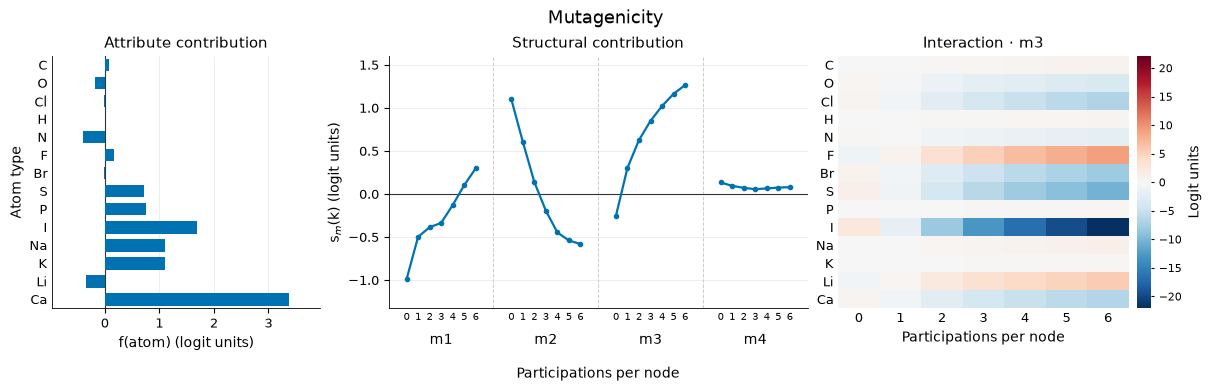

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plot_mignan_row(
    model,
    preprocessing,
    vocabulary,
    motif=3,
    figsize=(12, 3.8),
    fontsize=10,  # Porta a 12 per testi ancora più grandi.
    save_path="figure/mutagenicity_global.pdf",
)
plt.show()

In [118]:
def plot_mutagenicity_channels(
    y_true, y_pred, phi_f, phi_s, phi_i,
    *, n_boot=10_000, seed=42, save_path=None,
):
    """
    Contributi medi firmati al logit, con bootstrap percentile 95% CI.

    Input: vettori 1D della stessa lunghezza, nello stesso ordine dei grafi.
    Etichette: 0/1; classe positiva = 1.
    phi_f/s/i: somme graph-level dei canali F/S/I, senza intercetta,
    coerenti con explanation["channels"] nel notebook; nessun valore
    assoluto o normalizzazione per numero di nodi.

    Il bootstrap ricampiona grafi separatamente entro TP e FN, mantenendo
    insieme i tre canali. Con un solo grafo il relativo CI è degenere.
    Restituisce (fig, ax). save_path, se specificato, salva un PDF.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    names = ("y_true", "y_pred", "phi_f", "phi_s", "phi_i")
    arrays = []
    for name, values in zip(names, (y_true, y_pred, phi_f, phi_s, phi_i)):
        array = np.asarray(values)
        if array.ndim != 1 or array.size == 0:
            raise ValueError(f"{name} deve essere un vettore 1D non vuoto.")
        if np.iscomplexobj(array):
            raise ValueError(f"{name} deve contenere valori reali.")
        try:
            array = array.astype(np.float64)
        except (TypeError, ValueError) as exc:
            raise ValueError(f"{name} deve contenere valori numerici.") from exc
        if not np.isfinite(array).all():
            raise ValueError(f"{name} contiene NaN o valori infiniti.")
        arrays.append(array)

    if len({a.size for a in arrays}) != 1:
        raise ValueError("Tutti gli input devono avere la stessa lunghezza.")

    y_true, y_pred, phi_f, phi_s, phi_i = arrays
    if not (np.isin(y_true, [0, 1]).all() and np.isin(y_pred, [0, 1]).all()):
        raise ValueError("y_true e y_pred devono contenere solo etichette 0/1.")
    if (
        isinstance(n_boot, (bool, np.bool_))
        or not isinstance(n_boot, (int, np.integer))
        or n_boot < 1
    ):
        raise ValueError("n_boot deve essere un intero positivo.")

    masks = (
        (y_true == 1) & (y_pred == 1),
        (y_true == 1) & (y_pred == 0),
    )
    counts = [int(mask.sum()) for mask in masks]
    if min(counts) == 0:
        raise ValueError("Sono necessari almeno un TP e un FN.")

    contributions = np.column_stack((phi_f, phi_s, phi_i))
    rng = np.random.default_rng(seed)
    means = np.empty((2, 3))
    intervals = np.empty((2, 2, 3))

    for group, mask in enumerate(masks):
        values = contributions[mask]
        n = len(values)
        means[group] = values.mean(axis=0)

        # Blocchi per limitare la memoria; stessi indici per F, S e I.
        bootstrap = np.empty((n_boot, 3))
        batch_size = max(1, min(256, 250_000 // n))
        for start in range(0, n_boot, batch_size):
            stop = min(start + batch_size, n_boot)
            indices = rng.integers(0, n, size=(stop - start, n))
            bootstrap[start:stop] = values[indices].mean(axis=1)
        intervals[group] = np.percentile(bootstrap, [2.5, 97.5], axis=0)

    style = {
        "font.family": "DejaVu Sans",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 7,
        "axes.linewidth": 0.6,
        "pdf.fonttype": 42,
        "text.usetex": False,
    }

    with plt.rc_context(style):
        fig, ax = plt.subplots(figsize=(3.4, 2.6), constrained_layout=True)
        x = np.arange(3)
        width = 0.32

        # Palette Okabe–Ito, colorblind-safe.
        for group, (label, color) in enumerate(
            zip(("TP", "FN"), ("#0072B2", "#D55E00"))
        ):
            positions = x + (group - 0.5) * width
            ax.bar(
                positions, means[group], width=width,
                color=color, edgecolor="white", linewidth=0.5,
                label=f"{label} (n={counts[group]})", zorder=3,
            )
            lower, upper = intervals[group]
            # Disegna gli estremi esatti anche se il CI non include la media.
            midpoint = (lower + upper) / 2
            ax.errorbar(
                positions, midpoint,
                yerr=np.vstack((midpoint - lower, upper - midpoint)),
                fmt="none", ecolor="#222222",
                elinewidth=0.8, capsize=2.5, capthick=0.8, zorder=4,
            )

        ax.axhline(0, color="#333333", linewidth=0.8, zorder=2)
        ax.set_xticks(x)
        ax.set_xticklabels(["Attributes (F)", "Structure (S)", "Interaction (I)"])
        ax.set_ylabel("Mean signed contribution\n(logit units)")
        ax.set_title("Mutagenicity", pad=29)
        ax.legend(
            loc="lower center", bbox_to_anchor=(0.5, 1.01),
            ncol=2, frameon=False, borderaxespad=0,
            handlelength=1.2, columnspacing=1.3,
        )
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="x", length=0, pad=6)
        ax.tick_params(axis="y", width=0.6, length=3)
        ax.set_axisbelow(True)
        ax.grid(axis="y", color="0.9", linewidth=0.5)
        ax.margins(x=0.08, y=0.15)

        if save_path is not None:
            fig.savefig(save_path, format="pdf", facecolor="white")

    return fig, ax


Grafi elaborati: 50/651
Grafi elaborati: 100/651
Grafi elaborati: 150/651
Grafi elaborati: 200/651
Grafi elaborati: 250/651
Grafi elaborati: 300/651
Grafi elaborati: 350/651
Grafi elaborati: 400/651
Grafi elaborati: 450/651
Grafi elaborati: 500/651
Grafi elaborati: 550/651
Grafi elaborati: 600/651
Grafi elaborati: 650/651
Grafi elaborati: 651/651
TP: 189 | FN: 101


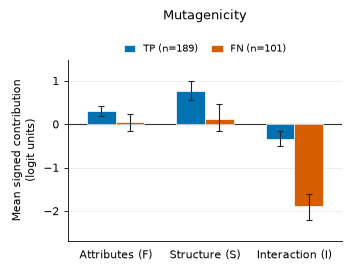

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from mignan.motifs import count_participation
from mignan.explain import explain_graph

if (
    preprocessing.task != "classification"
    or preprocessing.outputs != 1
    or not np.array_equal(preprocessing.classes, [0, 1])
):
    raise ValueError("È richiesto il modello binario Mutagenicity con classi 0/1.")

if not graphs_test:
    raise ValueError("graphs_test è vuoto.")

y_true = np.empty(len(graphs_test), dtype=int)
y_pred = np.empty(len(graphs_test), dtype=int)
phi_f = np.empty(len(graphs_test), dtype=float)
phi_s = np.empty(len(graphs_test), dtype=float)
phi_i = np.empty(len(graphs_test), dtype=float)

for j, test_graph in enumerate(graphs_test):
    if test_graph.y not in (0, 1):
        raise ValueError(f"Il grafo {j} non ha un'etichetta binaria.")

    # Usa il vocabolario del checkpoint, senza ripetere la discovery.
    [test_counts], [test_occurrences] = count_participation(
        [test_graph], vocabulary
    )
    test_explanation = explain_graph(
        model,
        test_graph,
        test_counts,
        test_occurrences,
        preprocessing,
        vocabulary,
        output_index=0,
    )

    y_true[j] = int(test_graph.y)
    y_pred[j] = int(test_explanation["prediction"] >= 0.5)

    # Somme firmate per grafo, già in unità di logit.
    phi_f[j] = float(test_explanation["channels"]["F"])
    phi_s[j] = float(test_explanation["channels"]["S"])
    phi_i[j] = float(test_explanation["channels"]["I"])

    if (j + 1) % 50 == 0 or j + 1 == len(graphs_test):
        print(f"Grafi elaborati: {j + 1}/{len(graphs_test)}")

print(
    f"TP: {np.sum((y_true == 1) & (y_pred == 1))} | "
    f"FN: {np.sum((y_true == 1) & (y_pred == 0))}"
)

fig, ax = plot_mutagenicity_channels(
    y_true=y_true,
    y_pred=y_pred,
    phi_f=phi_f,
    phi_s=phi_s,
    phi_i=phi_i,
    n_boot=10_000,
    seed=42,
    save_path=None,  # None per non salvare.
)
plt.show()


## 1. Learned feature functions

Choose a logical feature. Categorical features show the centered lookup table;
numerical features show the learned function over the training mean ± three
standard deviations. Shapes are displayed in model units (standardized target
units for regression). The separate factors have non-unique scales and signs;
interpret their products when studying interactions.

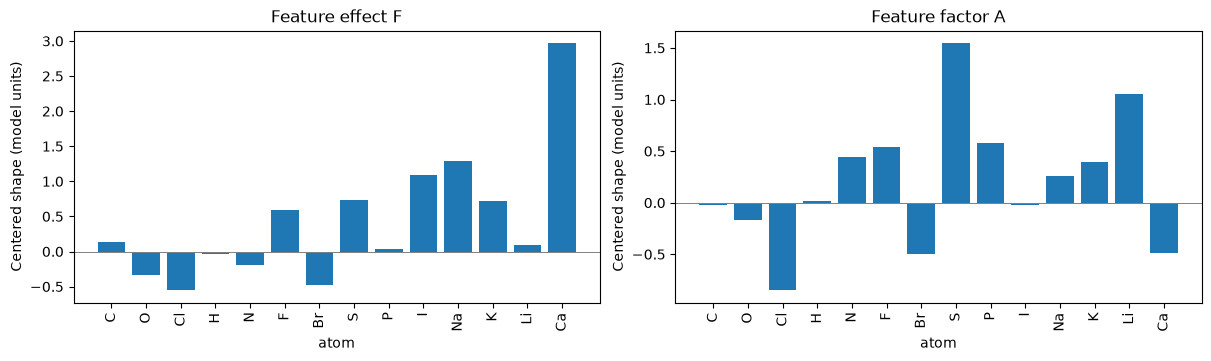

,F,A
C,0.138225,-0.020709
O,-0.328047,-0.172024
Cl,-0.555199,-0.850791
H,-0.035355,0.012684
N,-0.186307,0.444853
F,0.594515,0.544235
Br,-0.471535,-0.495323
S,0.740299,1.547426
P,0.036820,0.577759
I,1.086091,-0.018679


In [78]:
FEATURE = preprocessing.schema[0].name
feature_index = next(i for i, feature in enumerate(preprocessing.schema) if feature.name == FEATURE)
feature = preprocessing.schema[feature_index]
if feature.kind == "numerical":
    raw = np.linspace(preprocessing.feature_mean[feature_index] - 3 * preprocessing.feature_scale[feature_index],
                      preprocessing.feature_mean[feature_index] + 3 * preprocessing.feature_scale[feature_index], 150)
    inputs = torch.tensor(((raw - preprocessing.feature_mean[feature_index]) /
                           preprocessing.feature_scale[feature_index])[:, None], dtype=torch.float32)
else:
    raw = np.arange(len(feature.categories))
    inputs = torch.tensor(raw, dtype=torch.long)

with torch.no_grad():
    effect = (model.feature_main.shapes[feature_index](inputs)[:, OUTPUT_INDEX]
              - model.mean_feature_main[feature_index, OUTPUT_INDEX]).numpy()
    factor = (model.feature_factor.shapes[feature_index](inputs)[:, OUTPUT_INDEX]
              - model.mean_feature_factor[feature_index, OUTPUT_INDEX]).numpy()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), constrained_layout=True)
for ax, values, title in zip(axes, (effect, factor), ("Feature effect F", "Feature factor A")):
    if feature.kind == "numerical":
        ax.plot(raw, values)
    else:
        ax.bar(raw, values)
        ax.set_xticks(raw, feature.categories, rotation=90)
    ax.axhline(0, color="gray", linewidth=0.7)
    ax.set(title=title, xlabel=FEATURE, ylabel="Centered shape (model units)")
plt.show()
if feature.kind != "numerical":
    display(pd.DataFrame({"F": effect, "A": factor}, index=feature.categories))

## 2. Learned motif functions

Choose a motif and the participation range to inspect. The drawing shows its
unlabeled structure. The curves use the saved topology scaler and centering;
`MAX_COUNT` is a display range, not an assertion about observed training counts.

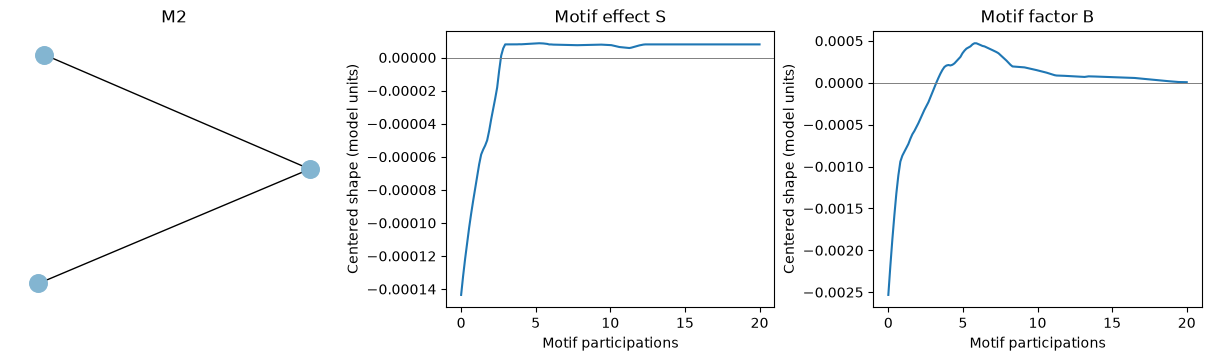

In [61]:
MOTIF = vocabulary.iloc[1]["motif"]
MAX_COUNT = 20
row = vocabulary.set_index("motif").loc[MOTIF]
motif_index = int(row["column"])
raw = np.linspace(0, MAX_COUNT, 150)
inputs = torch.tensor(((np.log1p(raw) - preprocessing.topology_mean[motif_index]) /
                       preprocessing.topology_scale[motif_index])[:, None], dtype=torch.float32)
with torch.no_grad():
    effect = (model.topology_main.shapes[motif_index](inputs)[:, OUTPUT_INDEX]
              - model.mean_topology_main[motif_index, OUTPUT_INDEX]).numpy()
    factor = (model.topology_factor.shapes[motif_index](inputs)[:, OUTPUT_INDEX]
              - model.mean_topology_factor[motif_index, OUTPUT_INDEX]).numpy()
template = nx.Graph()
template.add_nodes_from(range(int(row["size"])))
template.add_edges_from(json.loads(row["template_edges"]))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
nx.draw_networkx(template, pos=nx.kamada_kawai_layout(template), ax=axes[0],
                 with_labels=False, node_size=160, node_color="#83b5d1")
axes[0].set_title(MOTIF)
axes[0].set_axis_off()
for ax, values, title in zip(axes[1:], (effect, factor), ("Motif effect S", "Motif factor B")):
    ax.plot(raw, values)
    ax.axhline(0, color="gray", linewidth=0.7)
    ax.set(title=title, xlabel="Motif participations", ylabel="Centered shape (model units)")
plt.show()

## 3. Load a graph from the saved split

The data fingerprint verifies features, graph structure, targets, and ordering.
Select a position within the saved split. For large datasets, this data-loading
step can take time. Reuse the motif cache when available; otherwise count only
the saved vocabulary on the selected graph, without rerunning motif discovery.

In [62]:
SPLIT = "test"  # "train", "validation", or "test".
GRAPH_POSITION = 10

graphs = load_dataset(metadata["dataset"], max_graphs=metadata["max_graphs"],
                      seed=metadata["subset_seed"])
if len(graphs) != metadata["graph_count"] or dataset_fingerprint(graphs) != metadata["data_sha256"]:
    raise ValueError("The dataset differs from the data used for this checkpoint")
with np.load(RUN_DIR / "split.npz", allow_pickle=False) as stored:
    split_indices = {key: stored[key] for key in ("train", "validation", "test")}
graph_id = int(split_indices[SPLIT][GRAPH_POSITION])
graph = graphs[graph_id]
key, expected_metadata = cache_identity(graphs, split_indices["train"], metadata["motif_options"])
cache_path = Path(CACHE_DIR) / f"candidates_{key}.npz"
if cache_path.is_file():
    raw = load_cache(cache_path, expected_metadata)
    cached = select_topology(raw, graphs, vocabulary=vocabulary)
    counts, occurrences = cached.counts[graph_id], cached.occurrences[graph_id]
    del cached, raw
    print("Reused candidate counts; enumerated occurrences for this graph")
else:
    graph_counts, graph_occurrences = count_participation([graph], vocabulary)
    counts, occurrences = graph_counts[0], graph_occurrences[0]
    print("Counted the saved motif vocabulary on this graph")
explanation = explain_graph(model, graph, counts, occurrences, preprocessing,
                            vocabulary, output_index=OUTPUT_INDEX)
print("Graph:", graph_id, "| split:", SPLIT, "| target:", graph.y)
if preprocessing.task == "regression":
    print("Prediction:", explanation["prediction"])
elif preprocessing.outputs == 1:
    print(f"P(class={preprocessing.classes[1]:g}):", explanation["prediction"])
else:
    display(pd.Series(explanation["prediction"], index=preprocessing.classes, name="class probability"))
print("Reconstruction errors:", explanation["errors"])

Reused candidate counts; enumerated occurrences for this graph
Graph: 85 | split: test | target: 7.0
Prediction: 7.006038266211796
Reconstruction errors: {'graph': np.float64(9.695007658905297e-07), 'motif_occurrences': 1.0658141036401503e-14, 'pair_occurrences': 0.0}


## 4. Exact local decomposition

Contributions are in logit units for classification and original target units
for regression. The node map shows F + S + I; the graph-level intercept is
separate. The interaction matrix includes all vocabulary motifs: absent motifs
can contribute through their zero-participation reference.

intercept    9.890765
F            0.000000
S           -2.884726
I            0.000000
dtype: float64

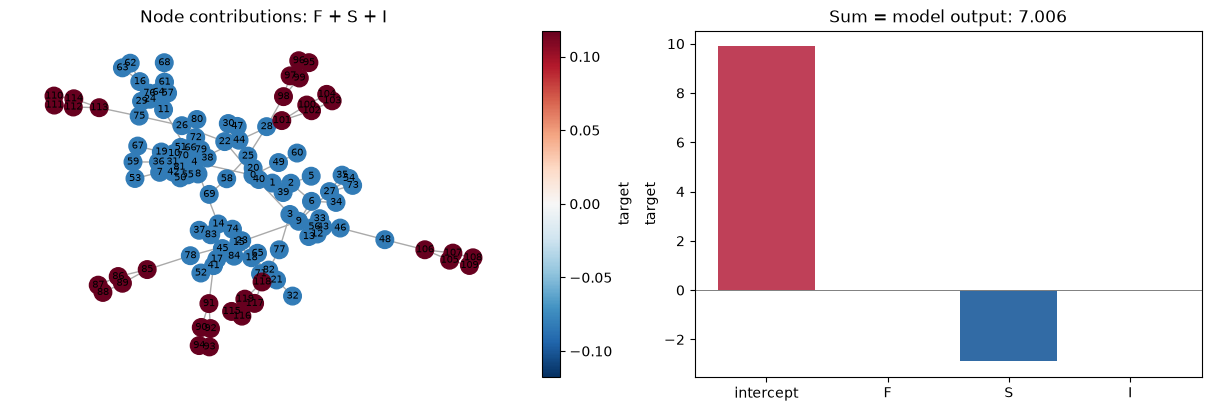

x1     0.0
x2     0.0
x3     0.0
x4     0.0
x5     0.0
x6     0.0
x7     0.0
x8     0.0
x9     0.0
x10    0.0
Name: feature contribution, dtype: float64

M1   -2.881428
M2   -0.001185
M3   -0.000118
M4   -0.003382
M5    0.001386
Name: motif contribution, dtype: float64

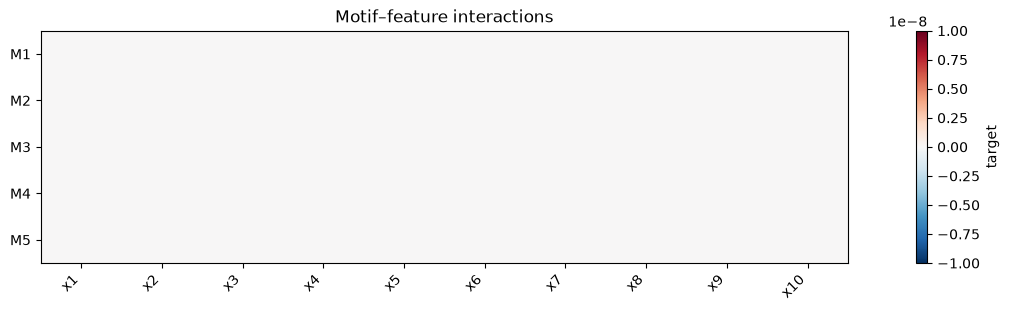

,motif,occurrence,nodes,structural,interaction,pairs
0,M1,0,"(85, 86, 87, 88, 89)",0.998514,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,M1,1,"(90, 91, 92, 93, 94)",0.998514,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,M1,2,"(95, 96, 97, 98, 99)",0.998514,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,M1,3,"(100, 101, 102, 103, 104)",0.998514,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,M1,4,"(105, 106, 107, 108, 109)",0.998514,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5,M1,5,"(110, 111, 112, 113, 114)",0.998514,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6,M1,6,"(115, 116, 117, 118, 119)",0.998514,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
7,M2,0,"(0, 1, 49)",0.000250,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
8,M2,1,"(0, 2, 49)",0.000207,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
9,M2,2,"(0, 3, 49)",0.000207,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


M1   -9.871028
M2   -0.093408
M3    0.000099
M4    0.003893
M5   -0.045264
Name: zero-participation reference, dtype: float64

In [63]:
display(explanation["channels"])
network = nx.Graph()
network.add_nodes_from(range(graph.num_nodes))
network.add_edges_from(graph.edge_index.T)
node_values = explanation["nodes"].sum(axis=1).to_numpy()
limit = max(float(np.abs(node_values).max()), 1e-8)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
positions = nx.spring_layout(network, seed=17)
nx.draw_networkx_edges(network, positions, ax=axes[0], edge_color="#aaaaaa")
points = nx.draw_networkx_nodes(network, positions, ax=axes[0], node_color=node_values,
                               cmap="RdBu_r", vmin=-limit, vmax=limit, node_size=160)
nx.draw_networkx_labels(network, positions, ax=axes[0], font_size=7)
axes[0].set_title("Node contributions: F + S + I")
axes[0].set_axis_off()
fig.colorbar(points, ax=axes[0], label=explanation["units"])
channels = explanation["channels"]
axes[1].bar(channels.index, channels.to_numpy(),
            color=["#bf4058" if value >= 0 else "#326ba5" for value in channels])
axes[1].axhline(0, color="gray", linewidth=0.7)
axes[1].set(title=f"Sum = model output: {explanation['output']:.4g}", ylabel=explanation["units"])
plt.show()

display(explanation["features"].rename("feature contribution"))
display(explanation["motifs"].rename("motif contribution"))
matrix = explanation["pairs"].T
limit = max(float(np.abs(matrix.to_numpy()).max()), 1e-8)
fig, ax = plt.subplots(figsize=(max(6, len(matrix.columns)), max(3, 0.3 * len(matrix))),
                       constrained_layout=True)
image = ax.imshow(matrix, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
ax.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(matrix)), matrix.index)
ax.set_title("Motif–feature interactions")
fig.colorbar(image, ax=ax, label=explanation["units"])
plt.show()
display(explanation["occurrences"].head(10))
display(explanation["zero_motifs"].rename("zero-participation reference"))

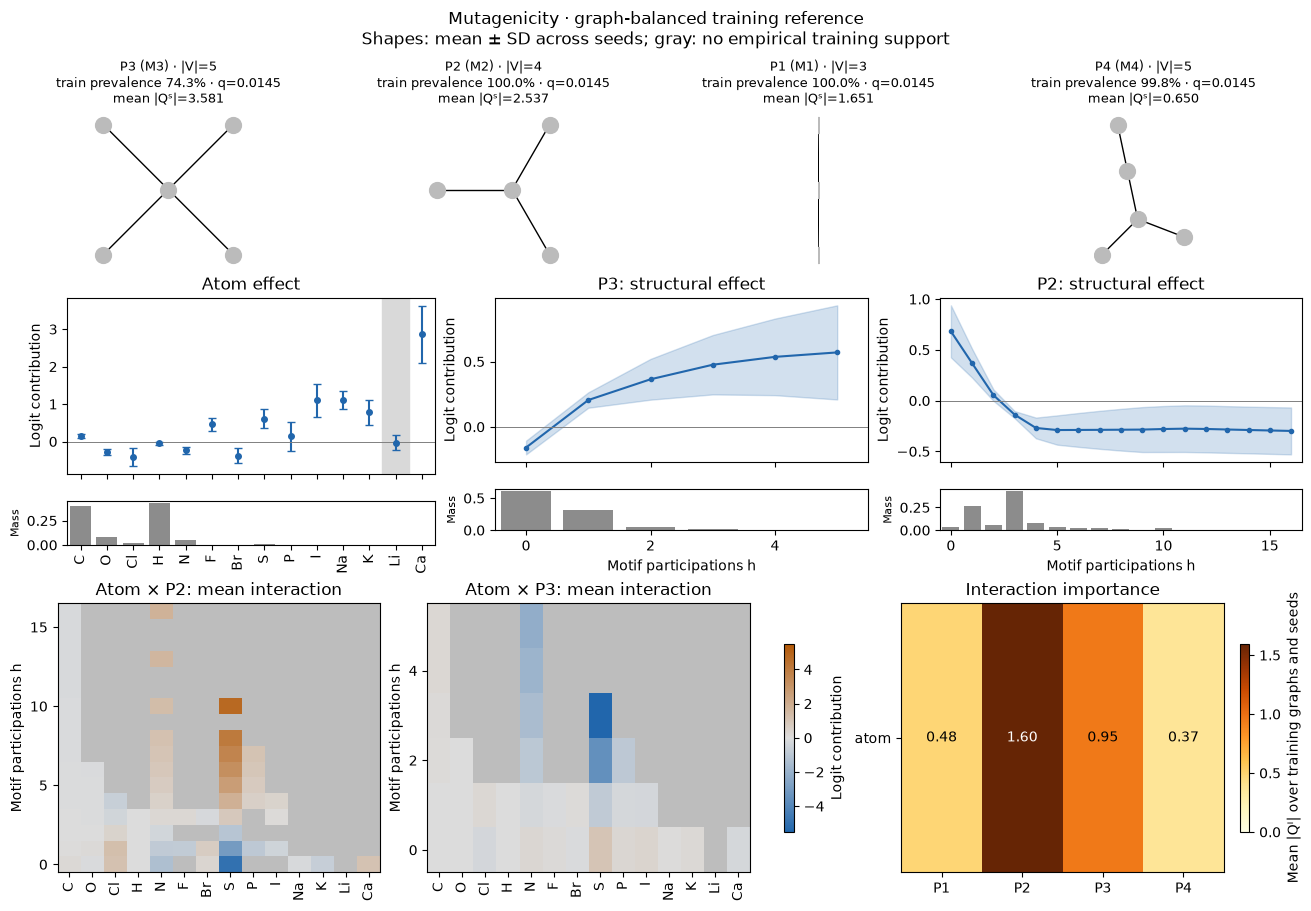

In [64]:
from mignan.paper_figures import (
    prepare_paper_figures,
    plot_global_explanation,
    plot_local_fme,
)

PAPER_RUN = Path(
    "/home/antonio/Clara/mignan_Clara/mignan/results/tuning/"
    "mutagenicity/20260916T174810677705Z"
)

# Carica i checkpoint esistenti; non addestra né ripete la discovery.
paper = prepare_paper_figures(PAPER_RUN, cache_dir=CACHE_DIR)

fig_global = plot_global_explanation(paper)
plt.show()

# fig_global.savefig("global_explanation.pdf", bbox_inches="tight", dpi=300)

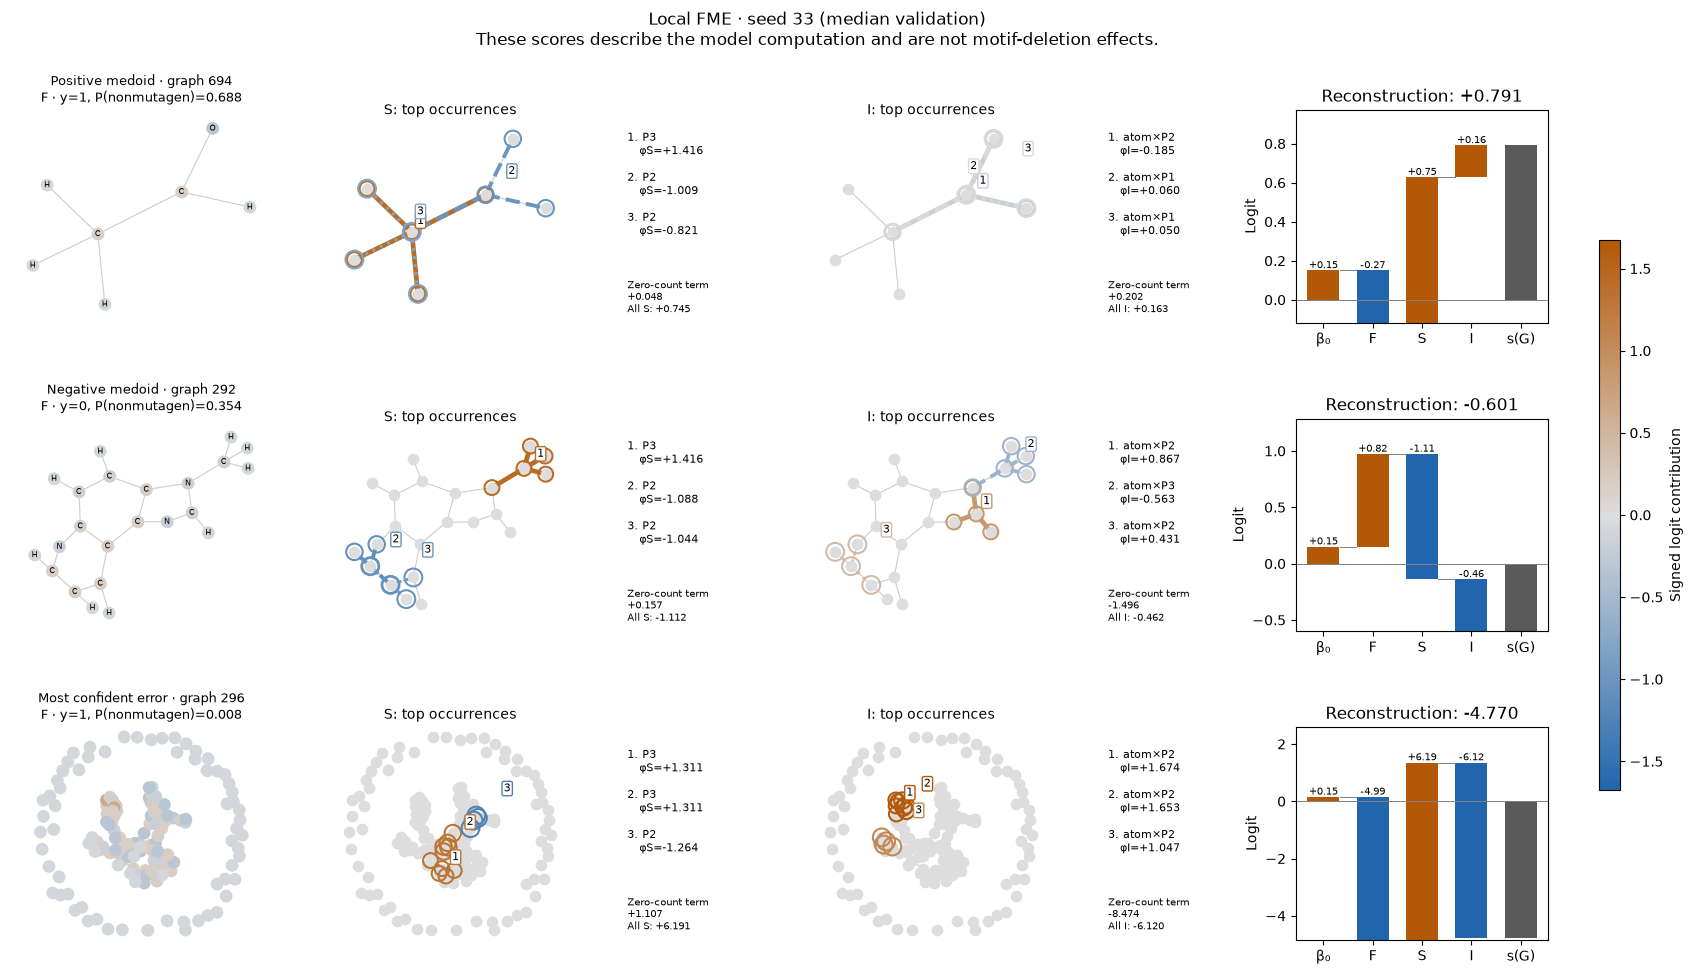

,case,graph_id,true_class,predicted_class,p_nonmutagen,seed,reconstruction_error
0,Positive medoid,694,1.0,1.0,0.688003,33,1.132462e-08
1,Negative medoid,292,0.0,0.0,0.354180,33,3.328666e-08
2,Most confident error,296,1.0,0.0,0.008410,33,3.263871e-07


In [65]:
fig_local, selected_cases = plot_local_fme(paper)
plt.show()

display(selected_cases)

# fig_local.savefig("local_fme.pdf", bbox_inches="tight", dpi=300)

In [66]:
paper

namespace(metadata={'format_version': 1,
                    'dataset': 'mutagenicity',
                    'task': 'classification',
                    'target': 'nonmutagen',
                    'max_graphs': None,
                    'subset_seed': 9182,
                    'split_seed': 2027,
                    'graph_count': 4337,
                    'data_sha256': 'a5c994a4d259bdb74ca6a79e433100985e9e44af4183e002df129b48b6812db8',
                    'model_options': {'hidden': 32,
                     'depth': 2,
                     'dropout': 0.0},
                    'training_options': {'epochs': 300,
                     'patience': 45,
                     'batch_size': 256,
                     'lr': 0.01,
                     'weight_decay': 1e-05,
                     'lambda_sparse': 0.001,
                     'device': 'cuda'},
                    'motif_options': {'sizes': [3, 4, 5],
                     'vocabulary_mode': 'enriched',
                     'null_re